## HW7: The Limitations of the Bootstrap Method
*(Just for fun so I use python for simplicity)*


In [1]:
# 导入库
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats
from collections import Counter
import random
random.seed(42)
np.random.seed(42)
# 中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False 

### 1. About Data

- The dataset originates from 3 photos of hospital **drainage devices** against specific backgrounds.
- Using visual priors and a BackgroundMattingV2 model, the devices were extracted from their backgrounds. 
- Following data augmentation, a ConvNeXt-Tiny model embedded the images into 648 **768-dimensional feature vectors**. 
- Finally, I calculated the 1-nearest neighbor distance for each vector and smoothed the resulting distribution using KDE, treating it as the **true population distribution**.

![图片描述](流程图.png)

In [2]:
data = np.load(r'G:\图片识别项目 - 副本\artifacts\HW7.npz', allow_pickle=True) # 加载特征向量
features = data['features'] 
print(f"特征矩阵形状: {features.shape}")

特征矩阵形状: (648, 768)


In [3]:
def normalize_l2(features):
    """L2 归一化"""
    norm = np.linalg.norm(features, axis=1, keepdims=True)
    return features / (norm + 1e-10)
features = normalize_l2(features)
cols = [f'feat_{i}' for i in range(features.shape[1])] # 转为 DataFrame
df = pd.DataFrame(features, columns=cols)
df.to_csv('features.csv', index=False) 
df.head()

,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_758,feat_759,feat_760,feat_761,feat_762,feat_763,feat_764,feat_765,feat_766,feat_767
0,0.006640,-0.008678,-0.017040,0.007580,0.003737,0.024464,0.011010,0.045463,-0.009026,0.008847,...,0.011710,-0.069441,0.001427,0.028882,0.045338,0.002651,-0.054128,-0.007131,-0.012305,-0.039010
1,0.011514,-0.009652,-0.016121,0.006847,0.014527,0.030724,0.005362,0.040135,-0.013026,0.004685,...,0.008729,-0.057764,0.000177,0.019380,0.042162,0.008015,-0.051334,-0.010707,-0.016247,-0.027555
2,0.013797,-0.011287,-0.014592,0.015023,0.014134,0.031984,0.005571,0.054675,-0.008882,0.008700,...,0.016721,-0.061958,0.004991,0.025440,0.048499,0.012131,-0.052978,-0.013668,-0.014595,-0.020709
3,0.016626,-0.019838,-0.016076,0.012730,0.014401,0.033547,0.002870,0.055331,-0.021165,0.004352,...,0.008959,-0.054508,0.001786,0.033612,0.045585,0.011679,-0.054491,-0.012843,-0.004239,-0.026291
4,0.014999,-0.021376,-0.018808,0.025226,0.013650,0.046034,0.001551,0.057431,-0.025538,0.001791,...,0.007323,-0.061807,0.006829,0.032090,0.047223,0.016824,-0.047806,-0.014414,0.002966,-0.022135


In [4]:
def distances(features):
    """
    计算每个样本与其最近邻的距离
    """
    n = len(features)
    sim_matrix = features @ features.T  # 余弦相似度矩阵
    dist_matrix = 1 - sim_matrix
    np.fill_diagonal(dist_matrix, np.inf)  
    dist_matrix = np.maximum(dist_matrix, 0)
    sorted_idx = np.argsort(dist_matrix, axis=1)  # 升序
    dists = np.array([
        float(dist_matrix[i, sorted_idx[i, 0]])
        for i in range(n)
    ])
    return dists

In [5]:
dists = distances(features)

In [6]:
def get_samples(kde, n1, num_samples):
    ''''从population中采样'''
    return [kde.resample(n1, seed=(it+6)**3)[0] for it in range(num_samples)]

In [7]:
def plot_all(dists, kde, true_val, true_samples, n1, B, colors, true_label='M', sample_label='m', fn=np.median):
    '''绘制讲义中的三列图'''
    num_samples = len(true_samples)
    nrows = num_samples + 1
    sns.set_style("white")
    all_samples = kde.resample(n1 * B).reshape(n1, B)
    sampling_stats = np.apply_along_axis(fn, 0, all_samples) # statistics of sampling distribution
    bootstrap_stats = []
    smooth_stats = []
    for sample in true_samples:
        boot_samples = np.random.choice(sample, size=(n1, B), replace=True) # bootstrap
        boot_stats = np.apply_along_axis(fn, 0, boot_samples) # statistics of bootstrap
        bootstrap_stats.append(boot_stats)
        s = np.std(sample, ddof=1)
        h = s / np.sqrt(n1) # kernel sd
        noise = np.random.normal(loc=0, scale=h, size=(n1, B))
        smooth_boot_stats = np.apply_along_axis(fn, 0, boot_samples + noise) # statistics of smoothed bootstrap
        smooth_stats.append(smooth_boot_stats)
    fig, axes = plt.subplots(nrows, 3, figsize=(18, 3 * nrows))

    def clean_ax(ax):
        ax.set_yticks([])
        ax.set_ylabel("")
        for spine in ['top', 'right', 'left']:
            ax.spines[spine].set_visible(False)

    # Population distribution + Sample
    ax = axes[0, 0]
    sns.kdeplot(dists, color="black", linewidth=1.5, ax=ax)
    ax.axvline(true_val, color='black', linestyle='-', linewidth=1.5)
    ax.set_title('Population', fontsize=12)
    clean_ax(ax)
    y_min, y_max = ax.get_ylim()
    ax.text(true_val, y_min - y_max * 0.05, f'${true_label}$', ha='center', va='top', fontsize=12)

    for i in range(num_samples):
        ax = axes[i + 1, 0]
        sample = true_samples[i]
        sample_stat = fn(sample)
        sns.histplot(sample, bins=15, color=colors[i], alpha=0.7, ax=ax)
        ax.axvline(true_val, color='black', linestyle='-', linewidth=1.5)
        ax.axvline(sample_stat, color='black', linestyle='--', linewidth=2)
        ax.set_title(f'Sample {i+1}', fontsize=12)
        clean_ax(ax)
        y_min, y_max = ax.get_ylim()
        ax.text(sample_stat, y_min - y_max * 0.1, f'${sample_label}$', ha='center', va='top', fontsize=12)

    # Sampling distribution + Bootstrap distribution
    ax = axes[0, 1]
    sns.kdeplot(sampling_stats, color="black", linewidth=1.5, ax=ax)
    ax.axvline(true_val, color='black', linestyle='-', linewidth=1.5)
    ax.set_title('Sampling Distribution', fontsize=12)
    clean_ax(ax)
    y_min, y_max = ax.get_ylim()
    ax.text(true_val, y_min - y_max * 0.05, f'${true_label}$', ha='center', va='top', fontsize=12)

    for i in range(num_samples):
        ax = axes[i + 1, 1]
        sample_stat = fn(true_samples[i])
        boot_stat = np.mean(bootstrap_stats[i])
        print(f"difference of statistics between bootstrap and sample {i+1}: {np.abs(boot_stat - sample_stat)}")
        sns.histplot(bootstrap_stats[i], bins=50, color=colors[i], alpha=0.7, edgecolor="none", ax=ax)
        ax.axvline(true_val, color='black', linestyle='-', linewidth=1.5)
        ax.axvline(sample_stat, color='black', linestyle='--', linewidth=2)
        #ax.axvline(boot_stat, color=colors[i], linestyle='--', linewidth=2)
        ax.set_title(f'Bootstrap distribution\nfrom sample {i+1}', fontsize=12)
        clean_ax(ax)
        y_min, y_max = ax.get_ylim()
        ax.text(sample_stat, y_min - y_max * 0.05, f'${sample_label}$', ha='center', va='top', fontsize=12)

    # Smoothed bootstrap distribution
    axes[0, 2].set_visible(False)

    for i in range(num_samples):
        ax = axes[i + 1, 2]
        sample_stat = fn(true_samples[i])
        sns.histplot(smooth_stats[i], bins=50, color=colors[i], alpha=0.7, edgecolor="none", ax=ax)
        ax.axvline(true_val, color='black', linestyle='-', linewidth=1.5)
        ax.axvline(sample_stat, color='black', linestyle='--', linewidth=2)
        ax.set_title(f'Smoothed bootstrap distribution\nfrom sample {i+1}', fontsize=12)
        clean_ax(ax)
        y_min, y_max = ax.get_ylim()
        ax.text(sample_stat, y_min - y_max * 0.05, f'${sample_label}$', ha='center', va='top', fontsize=12)

    for col in range(3):
        col_axes = [axes[r, col] for r in range(nrows) if axes[r, col].get_visible()]
        if not col_axes:
            continue
        x_min = min(ax.get_xlim()[0] for ax in col_axes)
        x_max = max(ax.get_xlim()[1] for ax in col_axes)
        for ax in col_axes:
            ax.set_xlim(x_min, x_max)
            ax.set_xticks([x_min, x_max])
            ax.xaxis.set_tick_params(labelbottom=False)
        col_axes[-1].xaxis.set_tick_params(labelbottom=True)
        col_axes[-1].xaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))

    plt.tight_layout()
    plt.show()

### 2. Bootstrap distributions for the median(n = 15)

- The left column shows the population and four samples. 
- The middle column shows the sampling distribution, and bootstrap distributions for each sample, with B = $10^4$. 
- The right column shows smoothed bootstrap distributions, with kernel sd $\frac{s}{\sqrt{n}}$ and B = $10^4$.

difference of statistics between bootstrap and sample 1: 0.0001305553065201158
difference of statistics between bootstrap and sample 2: 0.00033014754106261944
difference of statistics between bootstrap and sample 3: 8.498082523657711e-05
difference of statistics between bootstrap and sample 4: 0.0002670980345671082


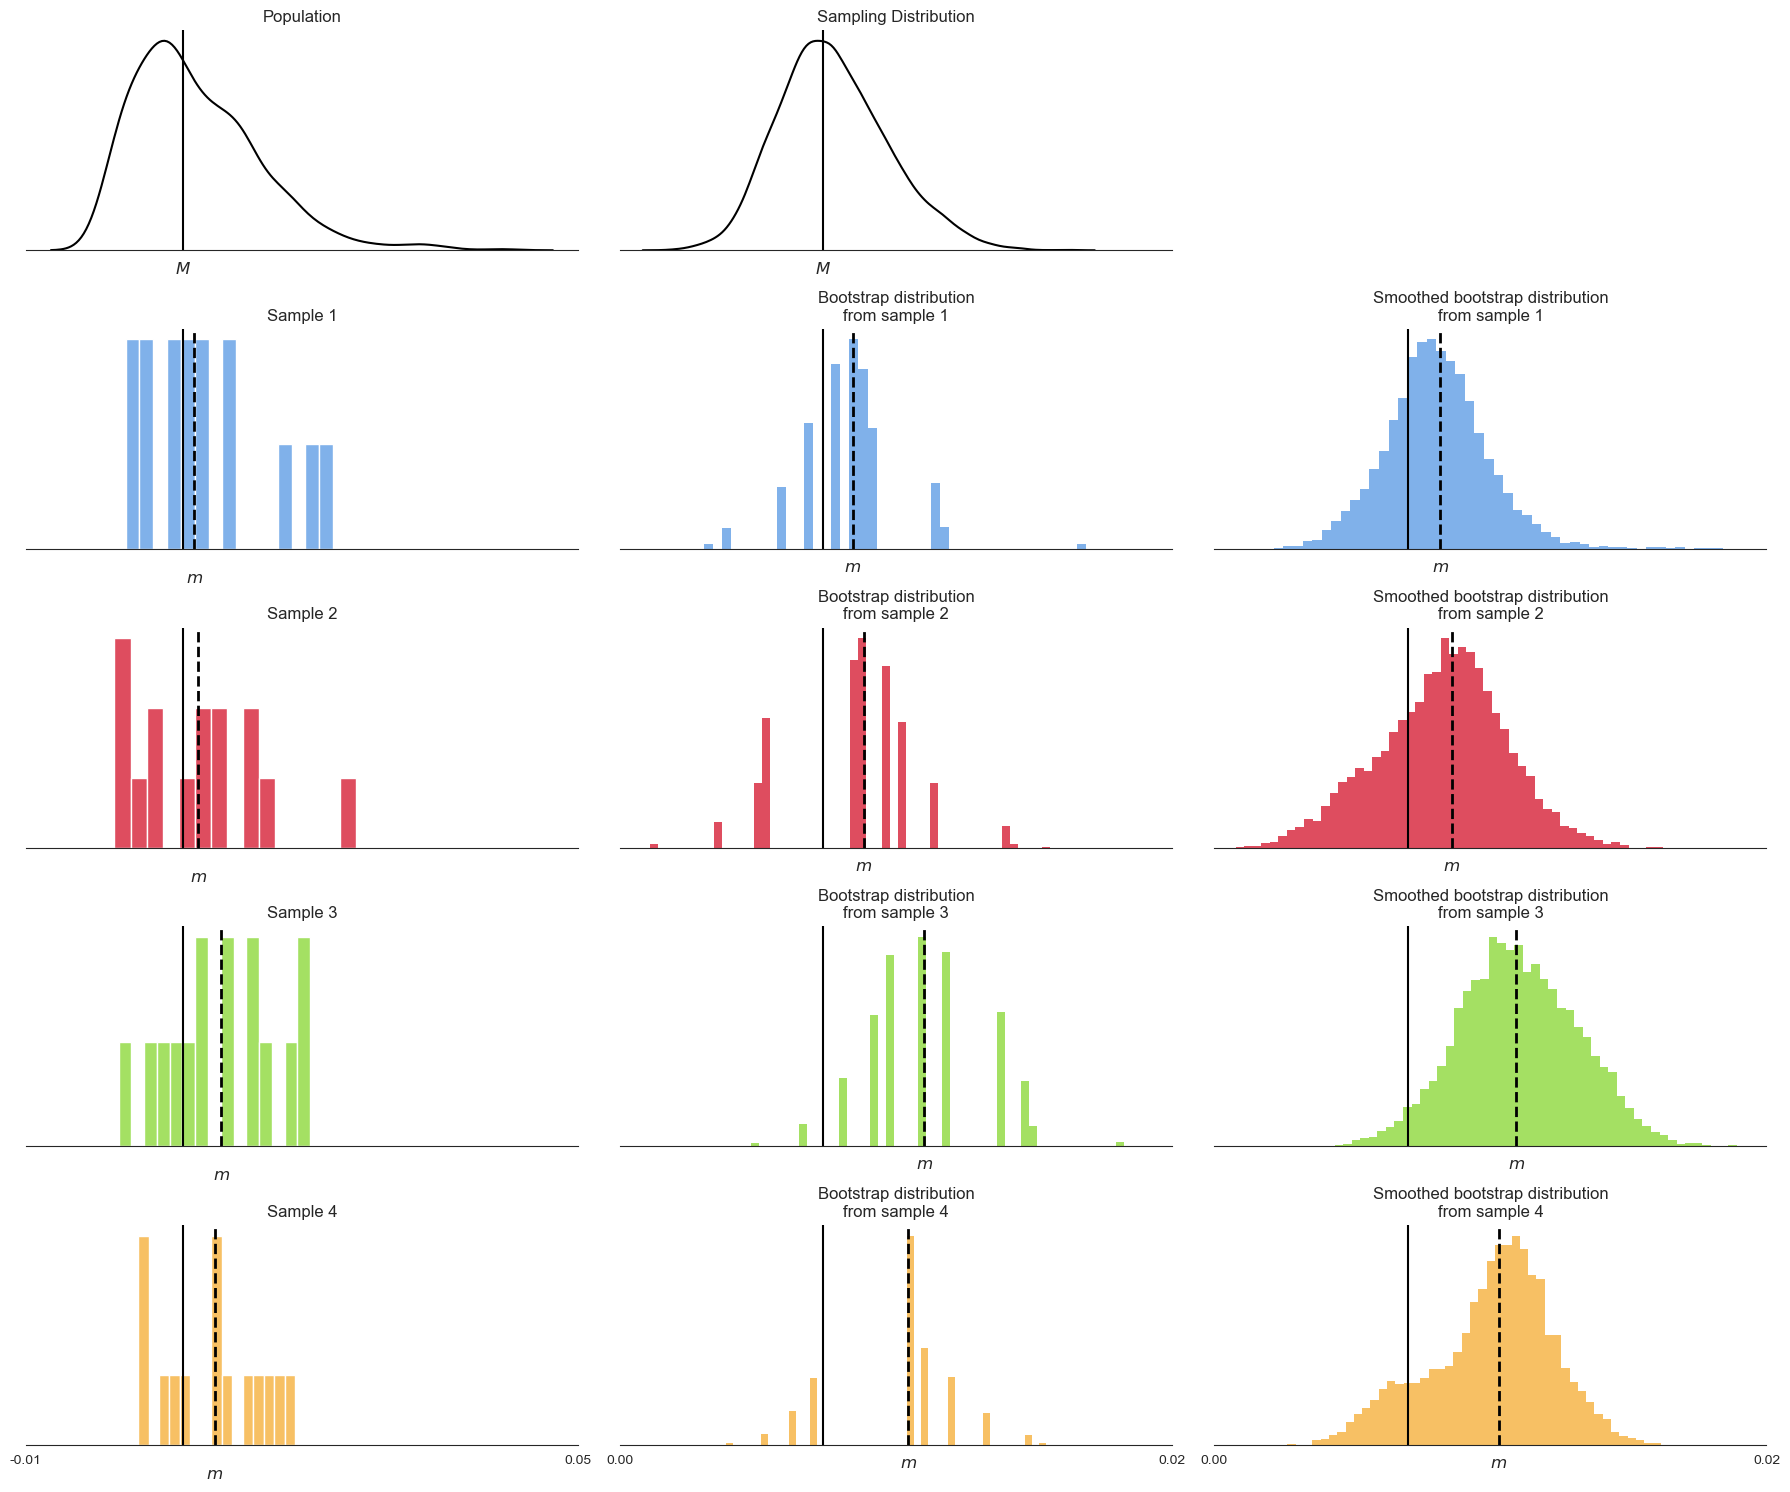

In [8]:
kde = stats.gaussian_kde(dists)
median_val = np.median(dists)
n1 = 15         
num_samples = 4
B = 10000
colors = ['#4A90E2', '#D0021B', '#7ED321', '#F5A623']
true_samples = get_samples(kde, n1, num_samples)
plot_all(dists, kde, median_val, true_samples, n1, B, colors,true_label='M', sample_label='m', fn=np.median) 

- Because $n=15$ is an odd number, the bootstrap sample median is forced to be exactly one of the original discrete observations. 
- The ordinary bootstrap provides a poor approximation of the true sampling distribution's shape.
- Instead of sampling from $F_n$, the smoothed bootsrap sample from a continuous $\hat F$ (KDE). It looks better, though is still poor for this small n.

### 3. Bootstrap distributions for the median(n = 50)

- Only increase the sample size: $n = 15$ **->** $n = 50$

difference of statistics between bootstrap and sample 1: 0.00011244732697874606
difference of statistics between bootstrap and sample 2: 4.6738120078474235e-05
difference of statistics between bootstrap and sample 3: 7.323039765520442e-05
difference of statistics between bootstrap and sample 4: 2.5698554016687775e-05


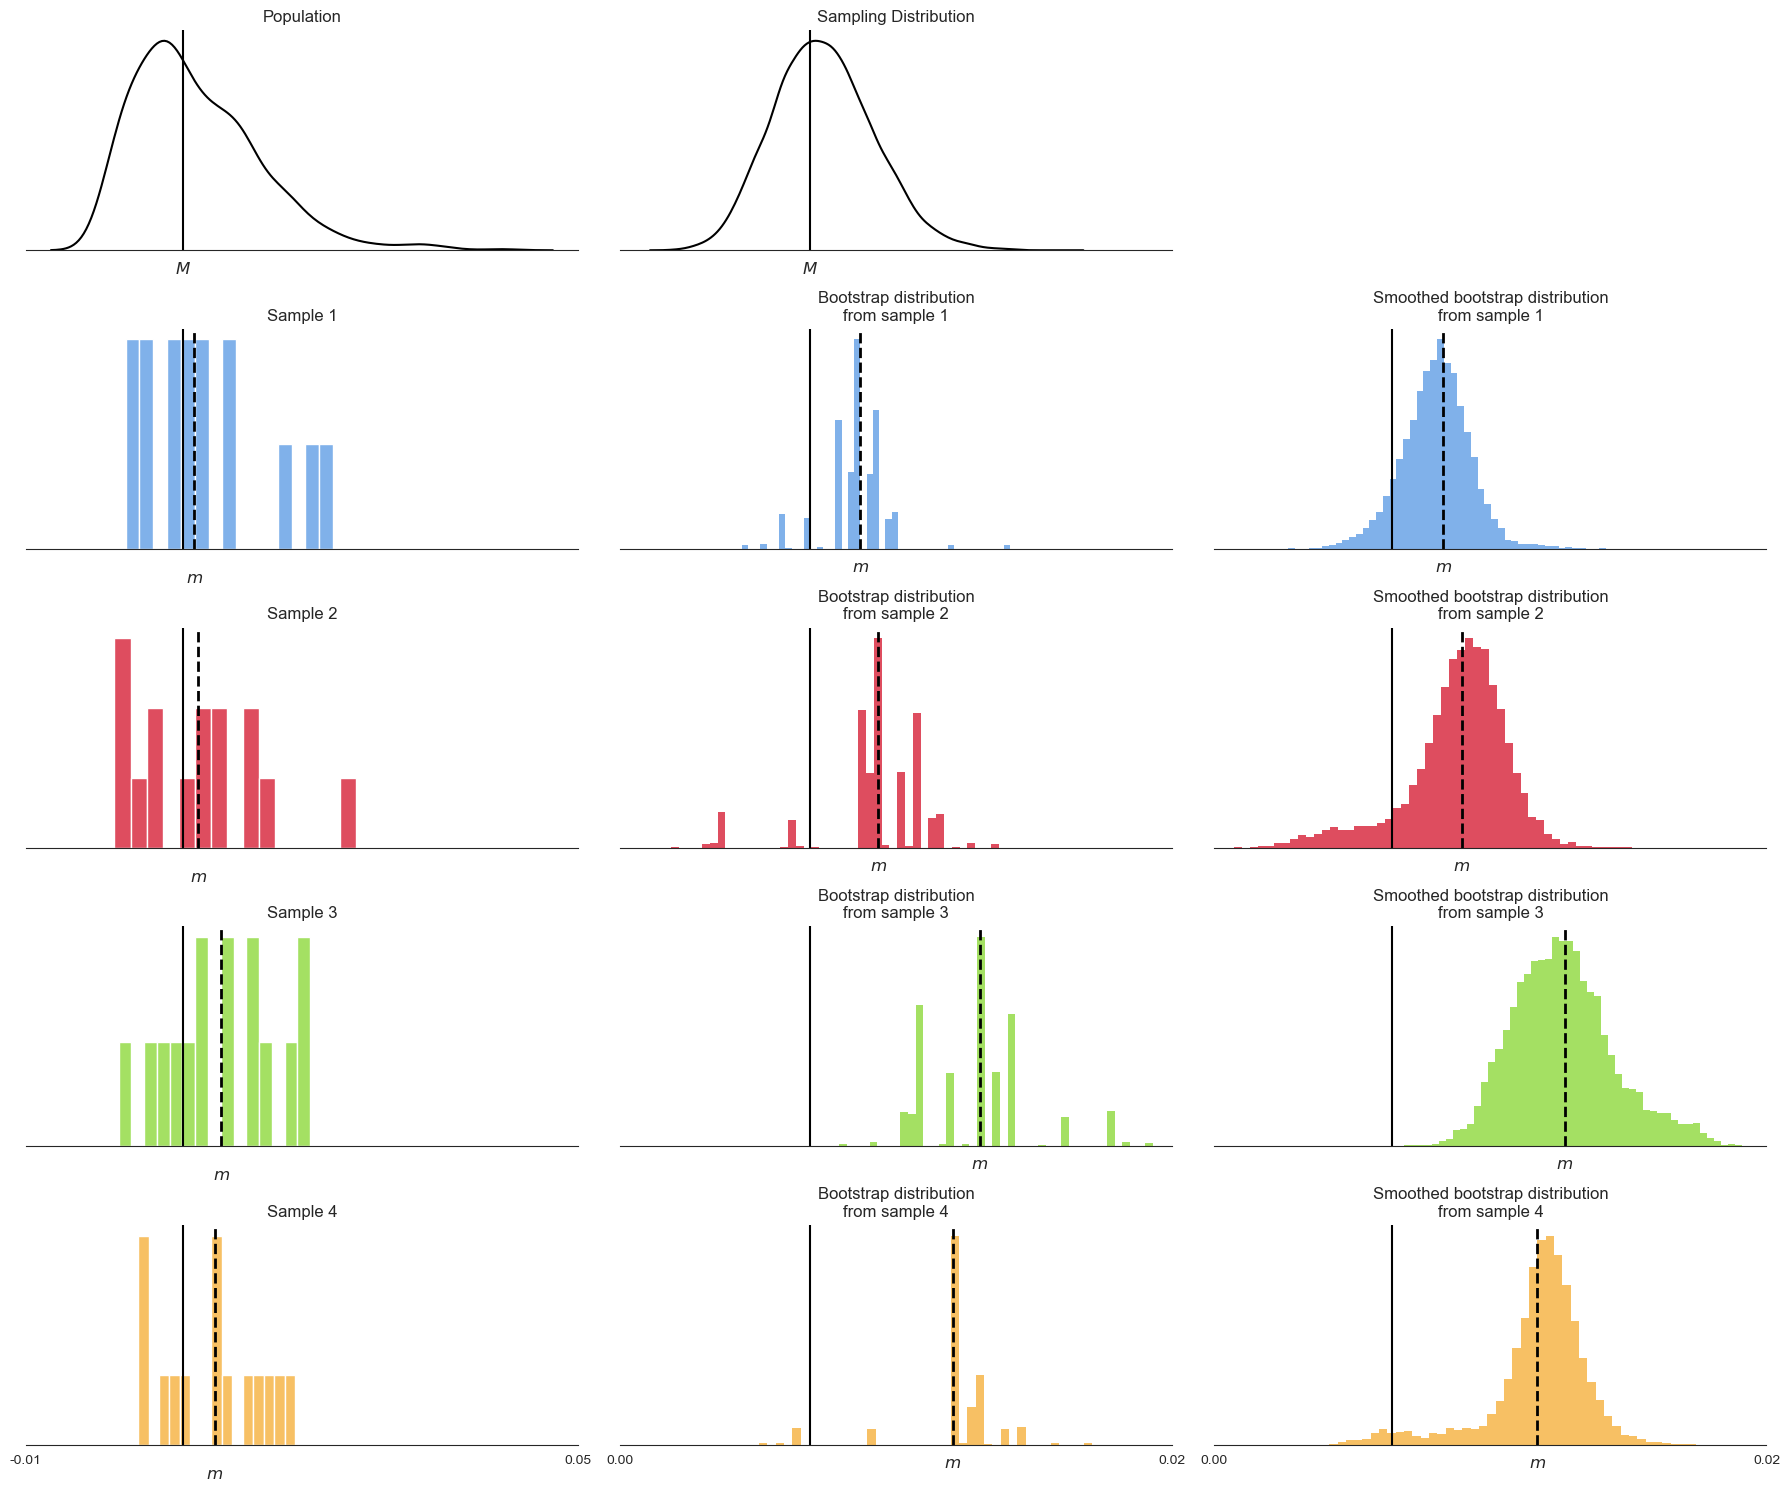

In [9]:
n2 = 50  
plot_all(dists, kde, median_val, true_samples, n2, B, colors,true_label='M', sample_label='m', fn=np.median) 

- The bootstrap approximates the continuous shape of the sampling distribution much more effectively due to the increased n, showing **decreased dependence** on the specific sample.
- The bootstrap does **not** provide a better point estimate of the population parameter, as it remains centered at the sample statistic.

### 4. Bootstrap distributions for 0.9 quantile(n = 15)
*same as before*

difference of statistics between bootstrap and sample 1: 0.0013706035893664877
difference of statistics between bootstrap and sample 2: 0.00113566093825564
difference of statistics between bootstrap and sample 3: 0.0010467399360300465
difference of statistics between bootstrap and sample 4: 0.0002214012341989098


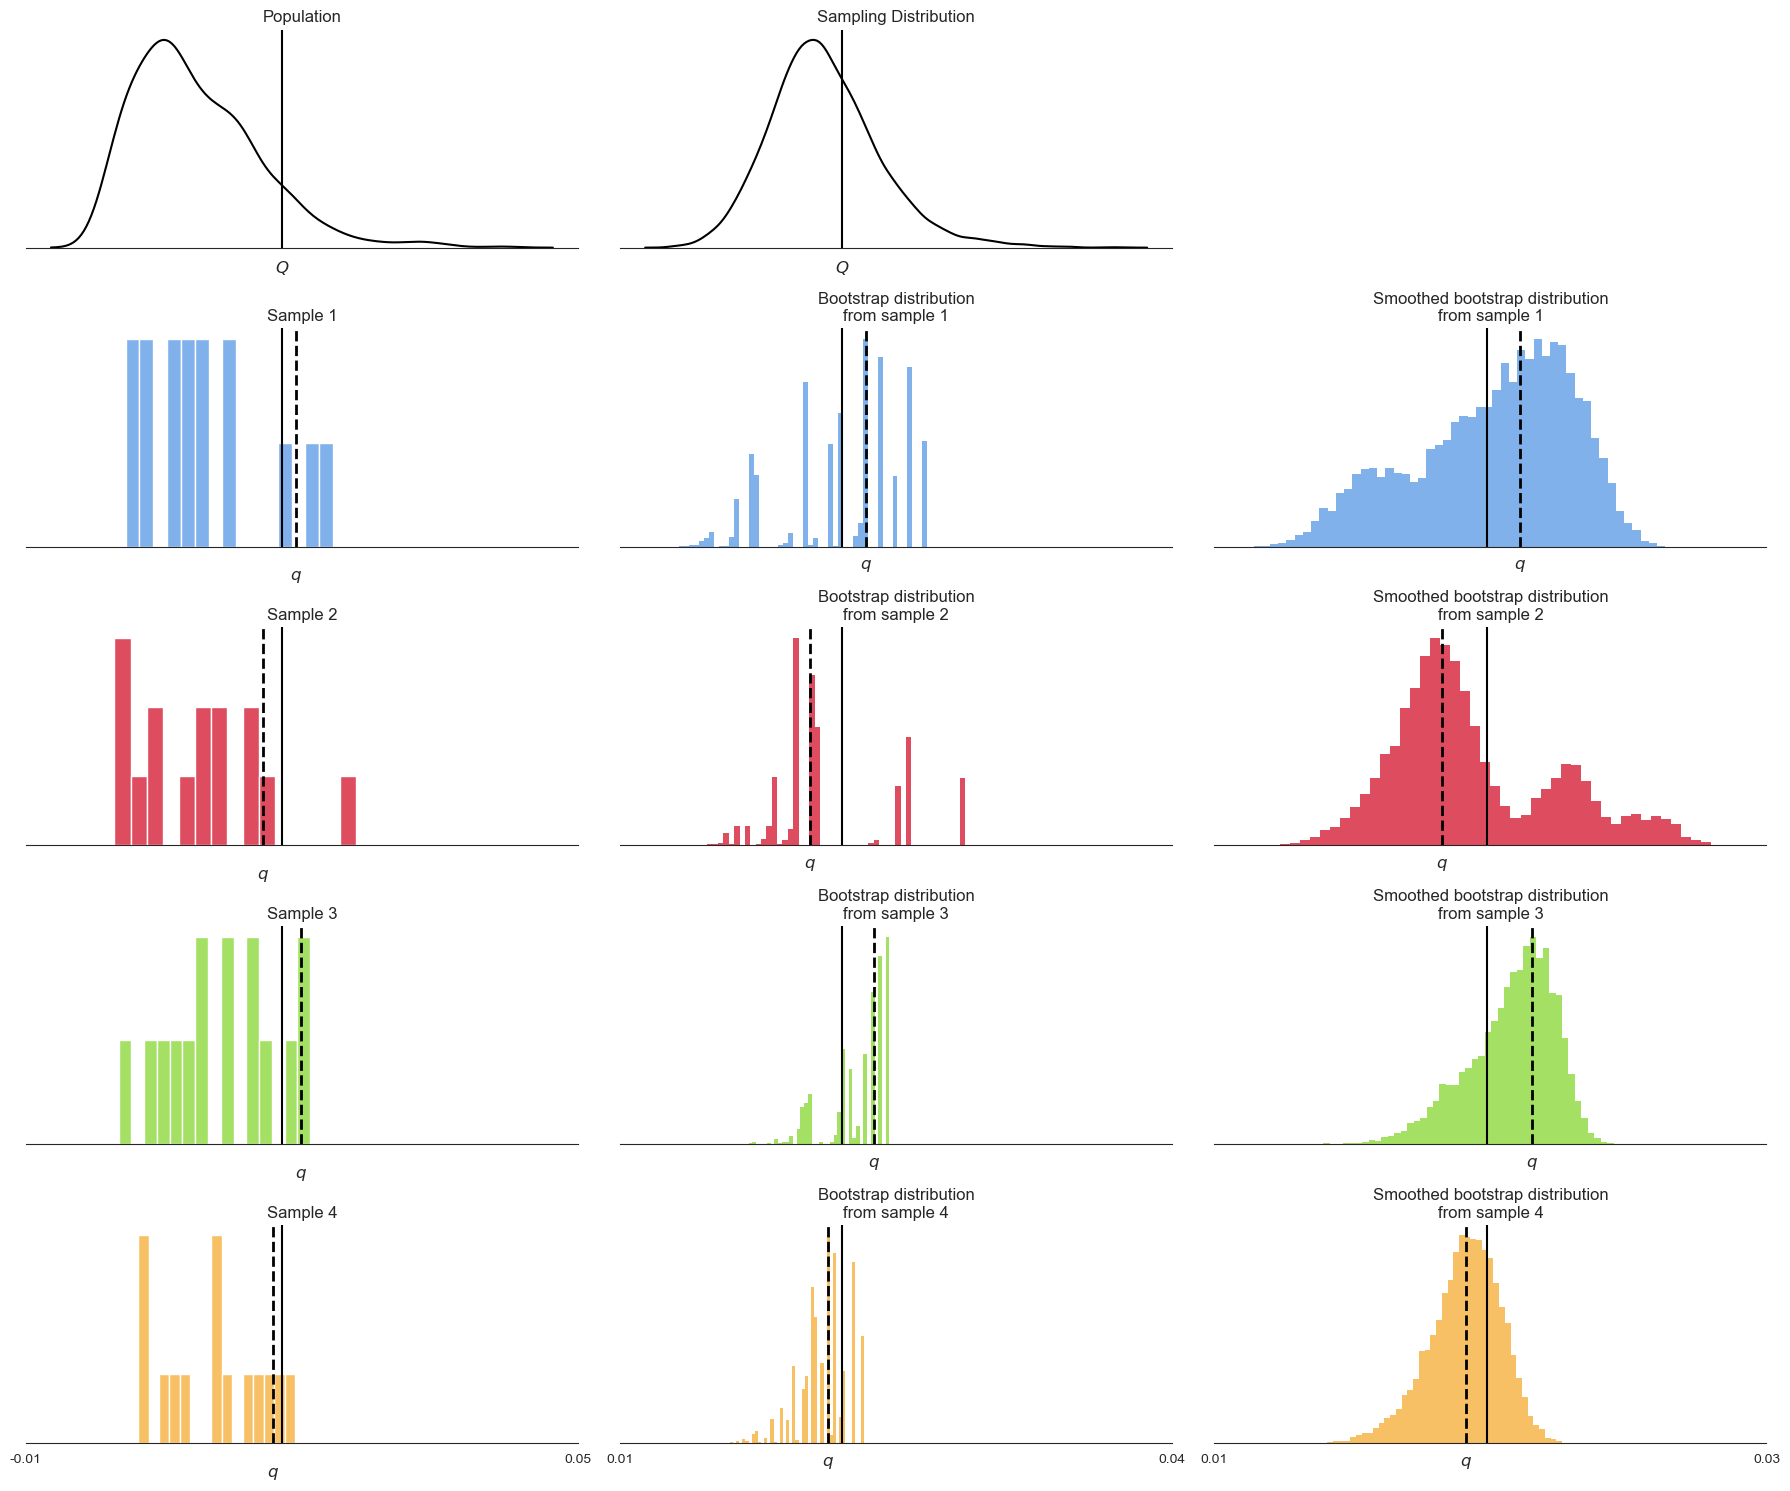

In [10]:
q90_val = np.percentile(dists, 90)
fn_q90 = lambda x: np.percentile(x, 90)
true_samples_q90 = get_samples(kde, n1, num_samples)
plot_all(dists, kde, q90_val, true_samples_q90, n1, B, colors,true_label='Q', sample_label='q', fn=fn_q90)

- The ordinary bootstrap distributions for the 0.9 quantile are even more **discrete**.(especially in sample1 & sample2)
- The centers of the bootstrap distributions (the sample 90th percentiles, indicated by dashed lines) **fluctuate wildly** across different samples.
- The smoothed bootsrap does **not** help a lot.

### 5. Bootstrap distributions for 0.9 quantile(n = 50)
*same as before(only increase the sample size n -> 50)*

difference of statistics between bootstrap and sample 1: 0.0003732091320582699
difference of statistics between bootstrap and sample 2: 0.0012675963380082526
difference of statistics between bootstrap and sample 3: 2.2242124159861654e-06
difference of statistics between bootstrap and sample 4: 0.0003038473190551498


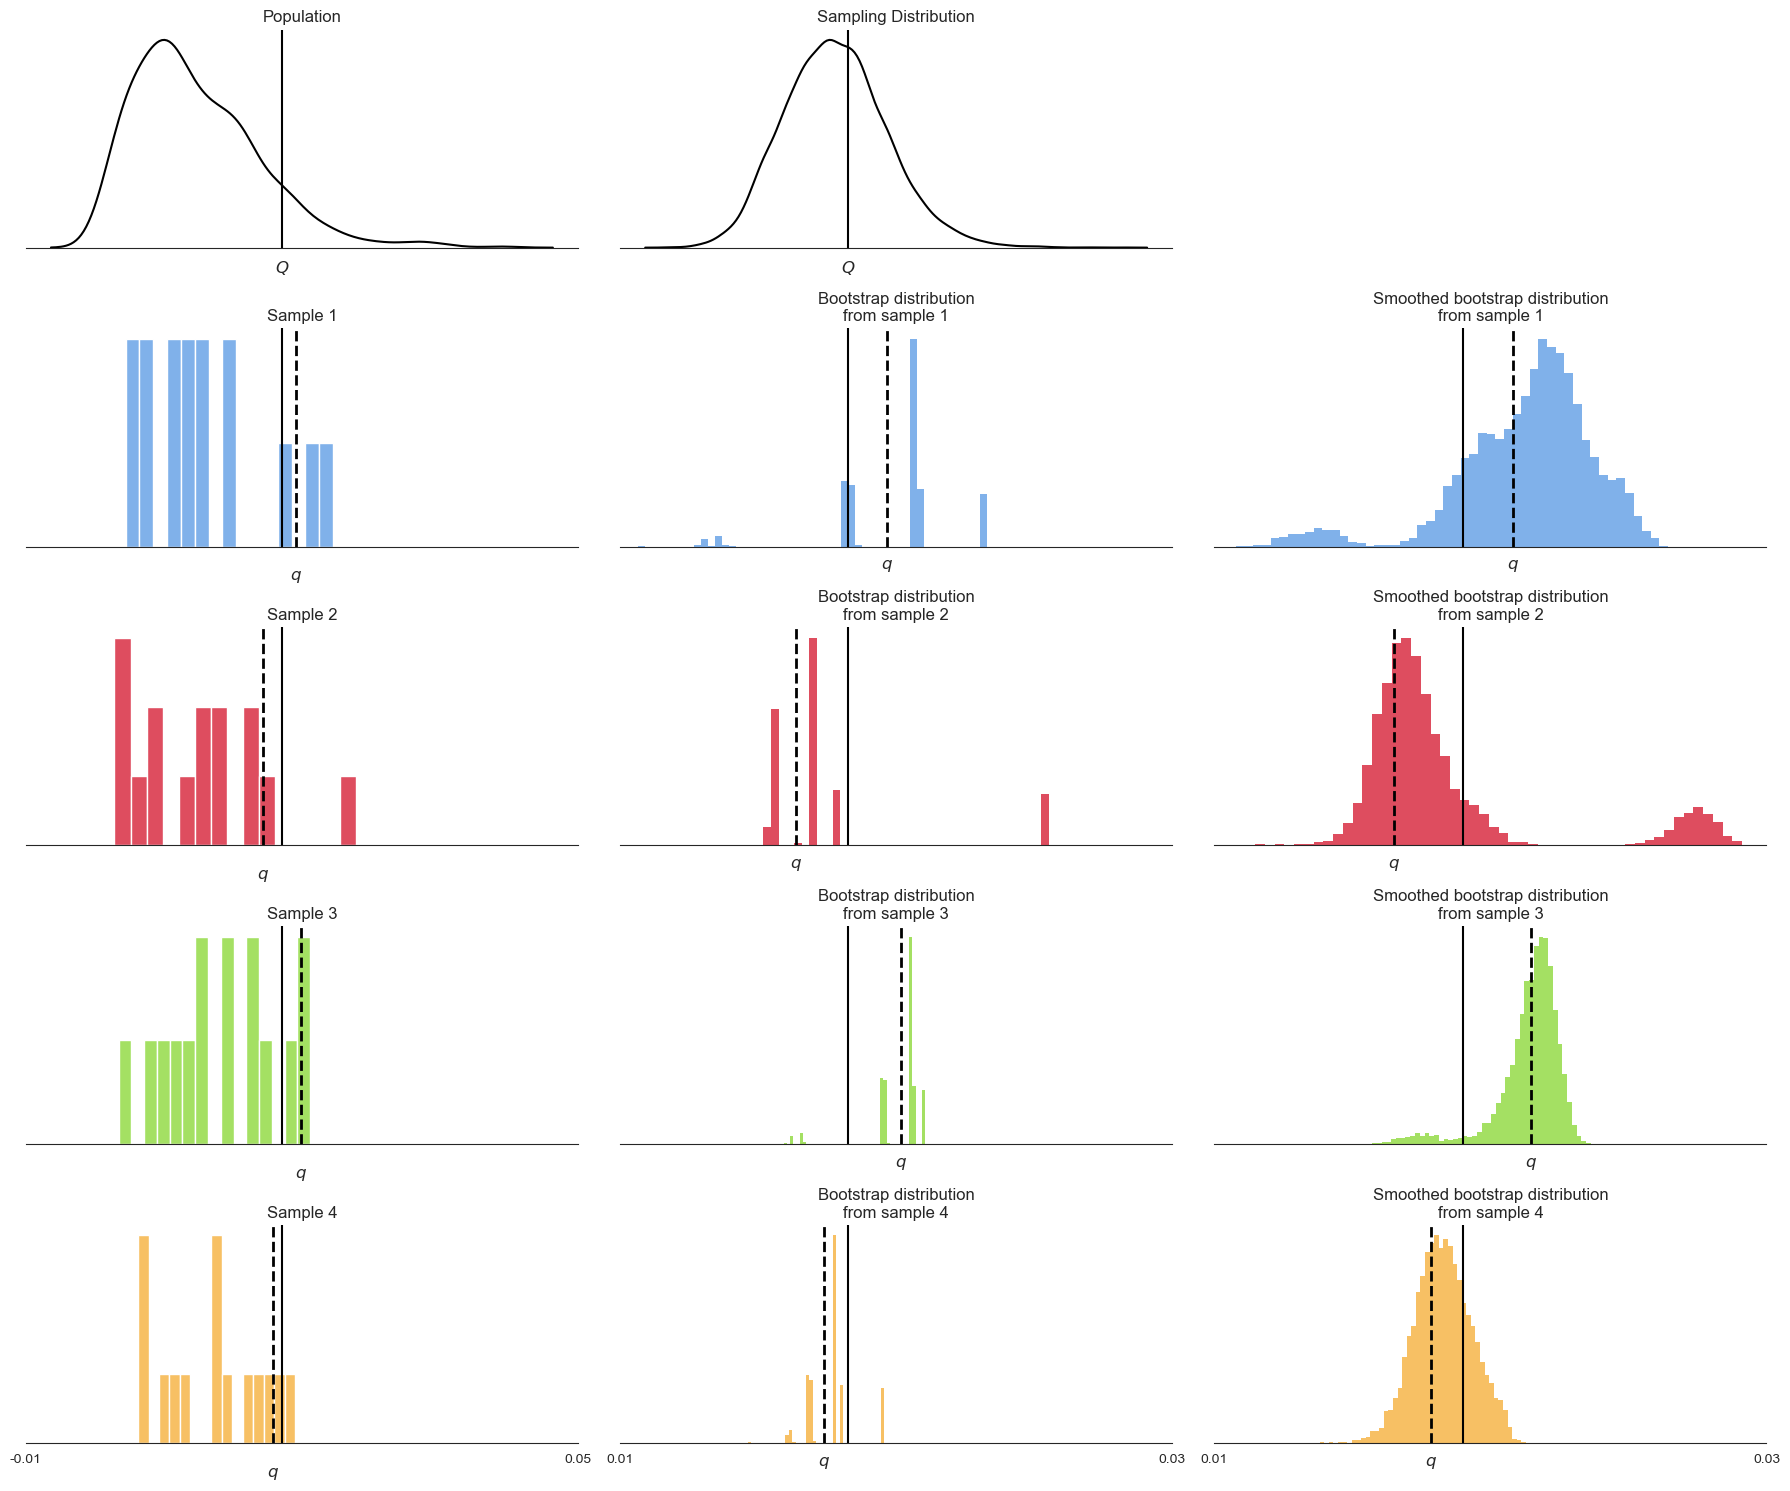

In [11]:
plot_all(dists, kde, q90_val, true_samples_q90, n2, B, colors,true_label='Q', sample_label='q', fn=fn_q90)

- Increasing the sample size n does **not** help a lot.

## 6. Conclusion
- The bootstrap **does not** provide a better estimate of the population parameter.  Instead, the bootstrap distributions are useful for estimating the
spread and shape of the sampling distribution.
- The ordinary bootstrap tends **not to work well** for statistics such as the **median**
or other **quantiles** in small samples. 
- The smoothed bootsrap is better, though is still poor.
- Increase the sample size may help.

### 7. Future Exploration

Ultimately, I aim to estimate the **0.99 quantile** of the 648-sample distribution to reject unknown objects that do not belong to our known classes. To achieve this, I compared 4 estimation methods:

- **Empirical Distribution**: Because of the discreteness and small sample size, this method can cause distinct extreme quantiles (e.g., the 90th and 99th percentiles) to output the same value.

- **KDE**: I attempted this previously, but it made no difference compared to the empirical distribution.

- **Bootstrap**: As discussed above, the bootstrap performs poorly on quantiles and does not provide a better estimate of the population parameter.

- **Bias-Corrected Bootstrap**: I have discussed this with Mrs. Wang, but its effectiveness remains uncertain and requires further testing.

The comparative results of these 4 methods are illustrated in the following figure.

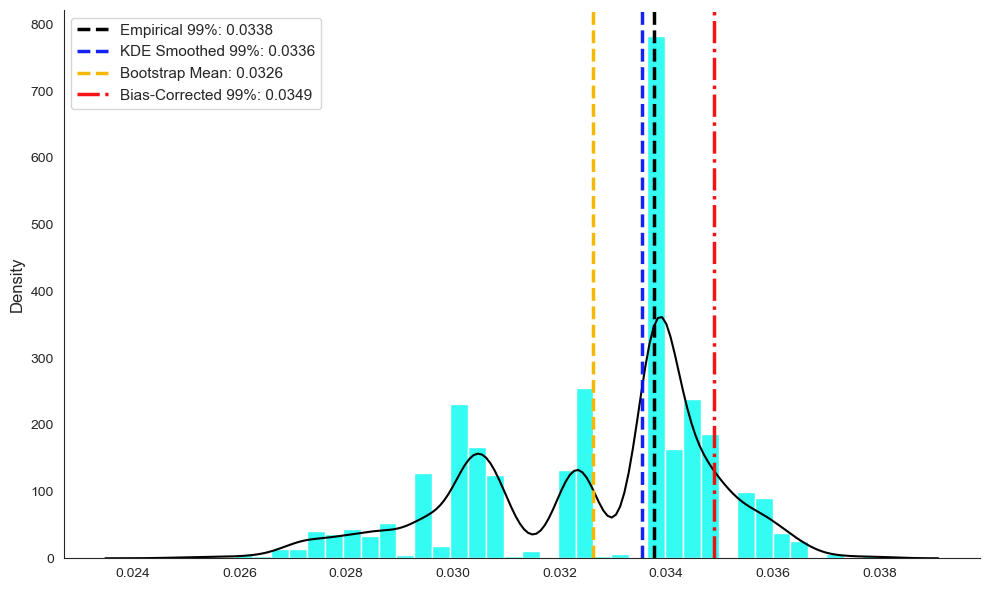

经验分布估计:       0.033765
KDE估计:        0.033553
Bootstrap均值:      0.032629
Bootstrap纠偏: 0.034901


In [12]:
n_total = len(dists)  # 648
q_emp = np.percentile(dists, 99) # 经验分布的 99% 分位数
sample_kde = kde.resample(1000000, seed=42)[0]
q_kde = np.percentile(sample_kde, 99) # KDE的 99% 分位数
    
boot_samples = np.random.choice(dists, size=(n_total, B), replace=True)
boot_q99 = np.percentile(boot_samples, 99, axis=0) # Bootstrap 的 99% 分位数
q_boot_mean = np.mean(boot_q99) # 用均值来估计

bias = q_boot_mean - q_emp
q_boot_bc = q_emp - bias # Bootstrap 纠偏

sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(boot_q99, bins=40, color="#01FCEF", stat="density", alpha=0.8, edgecolor="white", ax=ax)
sns.kdeplot(boot_q99, color="black", linewidth=1.5, ax=ax)
ax.axvline(q_emp, color='black', linestyle='--', linewidth=2.5, 
           label=f'Empirical 99%: {q_emp:.4f}')
ax.axvline(q_kde, color="#0414F1EF", linestyle='--', linewidth=2.5, 
           label=f'KDE Smoothed 99%: {q_kde:.4f}')
ax.axvline(q_boot_mean, color="#F5B804", linestyle='--', linewidth=2.5, 
           label=f'Bootstrap Mean: {q_boot_mean:.4f}')
ax.axvline(q_boot_bc, color="#F60505F1", linestyle='-.', linewidth=2.5, 
           label=f'Bias-Corrected 99%: {q_boot_bc:.4f}')
ax.set_ylabel('Density', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper left', fontsize=11, frameon=True)
plt.tight_layout()
plt.show()

print(f"经验分布估计:       {q_emp:.6f}")
print(f"KDE估计:        {q_kde:.6f}")
print(f"Bootstrap均值:      {q_boot_mean:.6f}")
print(f"Bootstrap纠偏: {q_boot_bc:.6f}")

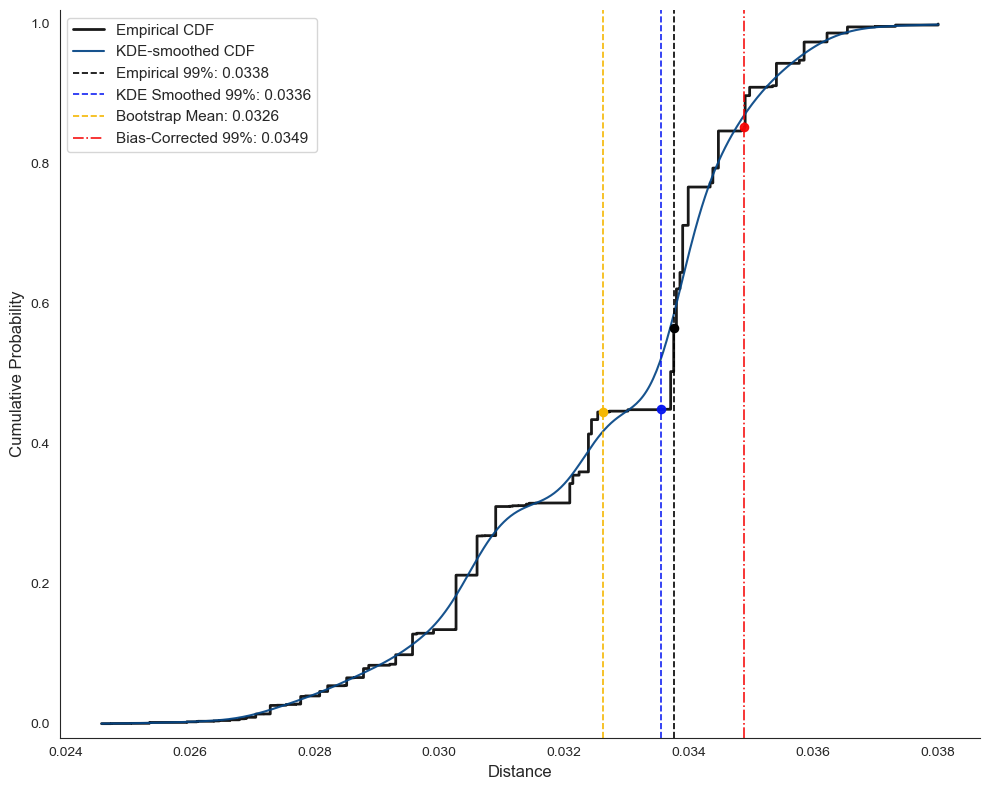

In [20]:
boot_sorted = np.sort(boot_q99)
boot_ecdf = np.arange(1, len(boot_sorted) + 1) / len(boot_sorted)

boot_kde = stats.gaussian_kde(boot_q99)
x_grid = np.linspace(boot_sorted.min(), boot_sorted.max(), 500)
kde_cdf = np.array([boot_kde.integrate_box_1d(-np.inf, x) for x in x_grid])

markers = [
    (q_emp, 'black', '--', f'Empirical 99%: {q_emp:.4f}'),
    (q_kde, "#0414F1EF", '--', f'KDE Smoothed 99%: {q_kde:.4f}'),
    (q_boot_mean, "#F5B804", '--', f'Bootstrap Mean: {q_boot_mean:.4f}'),
    (q_boot_bc, "#F60505F1", '-.', f'Bias-Corrected 99%: {q_boot_bc:.4f}'),
]

sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 8))
ax.step(boot_sorted, boot_ecdf, where="post", color="black", linewidth=2, alpha=0.9, label="Empirical CDF")
ax.plot(x_grid, kde_cdf, color="#054686ED", linewidth=1.5, label="KDE-smoothed CDF")

for value, color, linestyle, label in markers:
    cdf_y = np.searchsorted(boot_sorted, value, side="right") / len(boot_sorted)
    ax.axvline(value, color=color, linestyle=linestyle, linewidth=1.2, label=label)
    ax.scatter(value, cdf_y, color=color, s=35, zorder=3)

ax.set_xlabel("Distance", fontsize=12)
ax.set_ylabel("Cumulative Probability", fontsize=12)
ax.set_ylim(-0.02, 1.02)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper left', fontsize=11, frameon=True)
plt.tight_layout()
plt.show()